# Random Forest Baseline
Same dataset, same feature set as `build_model_weather.ipynb` (LightGBM) and
`build_model_lr.ipynb` (Linear Regression). This sits between the two in the
comparison chain: like LR it needs categoricals explicitly encoded (sklearn
trees don't accept raw categorical/string dtypes the way LightGBM does), but
like LightGBM it's a tree ensemble, so no feature scaling is needed and
it can capture non-linear interactions LR can't.

**Split strategy note:** same as the other notebooks — random group-split by
`trip_id` for the current single-day dataset. Switch `USE_CHRONOLOGICAL_SPLIT`
to `True` once the dataset spans multiple months, and keep this setting
consistent across all baseline notebooks so results stay comparable.

In [9]:
import numpy as np
import polars as pl
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import joblib

In [10]:
DATA_PATH = "raw/processed_gtfs/baseline_dataset.parquet"

# Toggle this once the dataset spans multiple months (see note above).
# Requires a `service_date` column in df.
USE_CHRONOLOGICAL_SPLIT = False
CHRONOLOGICAL_SPLIT_DATE = "2026-06-01"  # train < this date, test >= this date

df = pl.read_parquet(DATA_PATH)
print(df.shape)

TARGET = "travel_time"
CATEGORICAL = ["route_id", "direction_id", "shape_id", "service_id", 'is_raining', 'is_snowing', 'is_fog', "is_weekend",
    "is_federal_holiday",
    "is_school_day",
    "has_major_event",]
NUMERIC = [
    "stop_sequence", "trip_progress",
    "hour", "weekday", "month", "is_peak",
    "scheduled_arrival", "scheduled_departure", "scheduled_segment_time",
    "stop_lat", "stop_lon", "latitude", "longitude", "bearing",
    'temperature_c', 'precipitation_mm', 'snowfall_cm', 'windspeed_kmh', 'weathercode',
    'segment_length',
    'scheduled_segment_speed_mps',
    'upstream_delay_seconds',
    'speed_mps',
    'headway_seconds',
    "ridership",
    "transfers",
]

FEATURES = CATEGORICAL + NUMERIC

(56764, 40)


## Split
Identical split logic to `build_model_lr.ipynb` / `build_model_weather.ipynb`
so all baselines are evaluated on the exact same train/test rows.

In [11]:
if USE_CHRONOLOGICAL_SPLIT:
    assert "service_date" in df.columns, "service_date column required for chronological split"

    train_df = df.filter(pl.col("service_date") < CHRONOLOGICAL_SPLIT_DATE)
    test_df = df.filter(pl.col("service_date") >= CHRONOLOGICAL_SPLIT_DATE)

    print(f"[chronological split @ {CHRONOLOGICAL_SPLIT_DATE}]")
    print(f"train: {train_df.shape} | test: {test_df.shape}")
    print(f"train trips: {train_df['trip_id'].n_unique():,} | "
          f"test trips: {test_df['trip_id'].n_unique():,} | "
          f"overlap: {len(set(train_df['trip_id']) & set(test_df['trip_id']))}")
else:
    groups = df["trip_id"].to_numpy()
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(df, groups=groups))

    train_df = df[train_idx]
    test_df = df[test_idx]

    print("[random group split by trip_id]")
    print(f"train: {train_df.shape} | test: {test_df.shape}")
    print(f"train trips: {train_df['trip_id'].n_unique():,} | "
          f"test trips: {test_df['trip_id'].n_unique():,} | "
          f"overlap: {len(set(train_df['trip_id']) & set(test_df['trip_id']))}")

[random group split by trip_id]
train: (45363, 40) | test: (11401, 40)
train trips: 996 | test trips: 250 | overlap: 0


## Convert to pandas
Same helper as `build_model_lr.ipynb` — categoricals become pandas
`category` dtype, numeric columns stay as-is (no scaling needed for trees).

In [12]:
def to_pandas_typed(pl_df: pl.DataFrame) -> pd.DataFrame:
    cols = {}
    for col in FEATURES:
        s = pl_df[col]
        if col in CATEGORICAL:
            cols[col] = pd.Series(s.to_list(), dtype="category")
        else:
            cols[col] = s.to_numpy()
    return pd.DataFrame(cols)

X_train = to_pandas_typed(train_df)
X_test = to_pandas_typed(test_df)
y_train = train_df[TARGET].to_numpy()
y_test = test_df[TARGET].to_numpy()

## Preprocessing + model pipeline
Unlike LightGBM, sklearn's `RandomForestRegressor` can't consume raw
categorical dtypes directly, so categoricals still need one-hot encoding
(`handle_unknown="ignore"` so a category only seen in test doesn't break
prediction). **No `StandardScaler`** here, unlike the LR notebook — tree
splits are invariant to monotonic transforms of a feature, so scaling numeric
columns would be wasted work.

`sparse_output=True` on the encoder for the same memory reason as the LR
notebook (avoids a dense one-hot matrix once the dataset grows to millions
of rows); `RandomForestRegressor` accepts sparse input for `fit`.

Hyperparameters are deliberately modest for a baseline — `n_estimators=300`,
capped depth via `min_samples_leaf`, `n_jobs=-1` to use all cores. Not tuned;
this is meant to be beaten by the more careful models further down the chain.

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), CATEGORICAL),
        ("num", "passthrough", NUMERIC),
    ]
)

model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=5,
        max_features="sqrt",
        n_jobs=-1,
        random_state=42,
    )),
])

model.fit(X_train, y_train)
print("model fit complete")

model fit complete


## Evaluate
Same metrics (MAE, RMSE, R²) and the same naive baseline comparison
(predicting `scheduled_segment_time` as-is) used in the other notebooks, so
all baselines are directly comparable.

In [14]:
preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print(f"MAE:  {mae:.1f} sec")
print(f"RMSE: {rmse:.1f} sec")
print(f"R2:   {r2:.4f}")
mape = mean_absolute_percentage_error(y_test, preds)
wape = np.abs(y_test - preds).sum() / np.abs(y_test).sum()

print(f"MAPE: {mape*100:.1f}%  (caution: unstable if travel_time has near-zero rows)")
print(f"WAPE: {wape*100:.1f}%")
# naive baseline for comparison: predict the scheduled segment time as-is
naive_preds = test_df["scheduled_segment_time"].to_numpy()
naive_mae = mean_absolute_error(y_test, naive_preds)
print(f"\nNaive baseline (scheduled_segment_time only) MAE: {naive_mae:.1f} sec")
print(f"Improvement over naive: {(1 - mae / naive_mae) * 100:.1f}%")
naive_wape = np.abs(y_test - naive_preds).sum() / np.abs(y_test).sum()
print(f"Naive baseline WAPE: {naive_wape*100:.1f}%")

MAE:  32.2 sec
RMSE: 58.0 sec
R2:   0.4823
MAPE: 73.4%  (caution: unstable if travel_time has near-zero rows)
WAPE: 32.7%

Naive baseline (scheduled_segment_time only) MAE: 47.4 sec
Improvement over naive: 32.0%
Naive baseline WAPE: 48.0%


## Feature importances
RF's analogue to LightGBM's `feature_importances_` — mean decrease in
impurity per (encoded) feature, averaged across all trees in the forest.

shape: (88, 2)
┌─────────────────────────────────┬────────────┐
│ feature                         ┆ importance │
│ ---                             ┆ ---        │
│ str                             ┆ f64        │
╞═════════════════════════════════╪════════════╡
│ num__segment_length             ┆ 0.245934   │
│ num__scheduled_segment_time     ┆ 0.120261   │
│ num__latitude                   ┆ 0.048921   │
│ num__stop_lat                   ┆ 0.042346   │
│ num__scheduled_segment_speed_m… ┆ 0.041312   │
│ …                               ┆ …          │
│ cat__is_weekend_0.0             ┆ 0.0        │
│ cat__is_federal_holiday_0.0     ┆ 0.0        │
│ cat__is_school_day_0.0          ┆ 0.0        │
│ cat__has_major_event_0.0        ┆ 0.0        │
│ num__snowfall_cm                ┆ 0.0        │
└─────────────────────────────────┴────────────┘


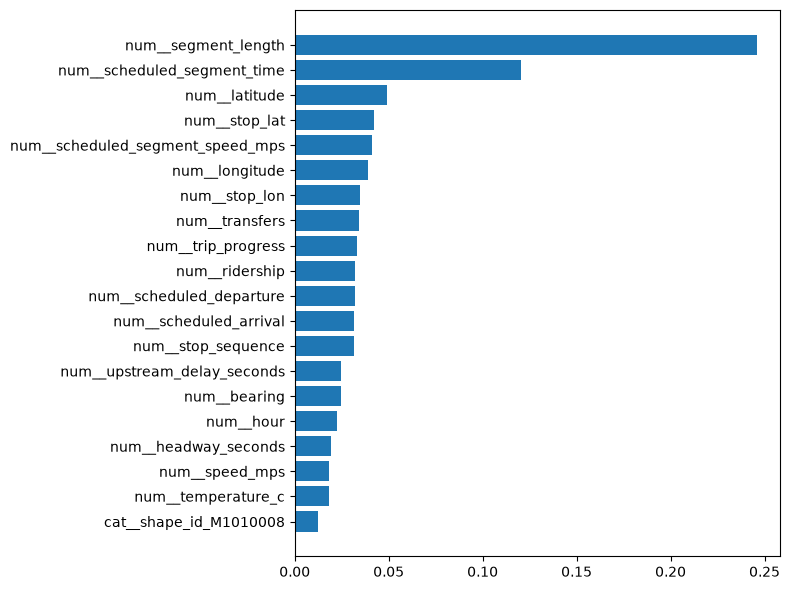

In [15]:
encoded_feature_names = model.named_steps["preprocess"].get_feature_names_out()
importances = model.named_steps["regressor"].feature_importances_

fi_df = pl.DataFrame({
    "feature": encoded_feature_names,
    "importance": importances,
}).sort("importance", descending=True)

print(fi_df)

import matplotlib.pyplot as plt

top = fi_df.head(20).to_pandas()
plt.figure(figsize=(8, 6))
plt.barh(top["feature"], top["importance"])
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Save
Saved as a `.pkl` via joblib, same as the LR notebook (a sklearn `Pipeline`
isn't natively dumpable to a lightweight text format the way LightGBM's
booster is). Naming mirrors the other baseline model files so all four are
easy to find together in `models/`.

In [ ]:
# joblib.dump(model, "models/rf_weather_segments_delay_and_ridership.pkl")
# print("model saved")

model saved
